In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import numpy as np

df = pd.read_csv('Indian_macro_data_ordered.csv')
df.head()

,DATE,INFLATION,REPO RATE
0,1/1/2014,8.60,8.0
1,1/2/2014,7.88,8.0
2,1/3/2014,8.25,8.0
3,1/4/2014,8.48,8.0
4,1/5/2014,8.33,8.0


In [4]:
%pip install pandas matplotlib statsmodels numpy


Note: you may need to restart the kernel to use updated packages.


In [5]:
df['DATE'] = pd.to_datetime(df['DATE'], dayfirst=True)
df = df.set_index('DATE').sort_index()
df.head()

,INFLATION,REPO RATE
DATE,,
2014-01-01,8.60,8.0
2014-02-01,7.88,8.0
2014-03-01,8.25,8.0
2014-04-01,8.48,8.0
2014-05-01,8.33,8.0


In [6]:
df.describe()

,INFLATION,REPO RATE
count,142.000000,144.000000
mean,4.881268,5.992361
std,1.696188,1.156244
min,0.250000,4.000000
25%,3.660000,5.400000
50%,4.960000,6.250000
75%,5.870000,6.500000
max,8.600000,8.000000


In [7]:
df.isna().sum()

INFLATION    2
REPO RATE    0
dtype: int64

In [8]:
df = df.dropna()

In [9]:
df.isna().sum()

INFLATION    0
REPO RATE    0
dtype: int64

In [10]:
df.describe()

,INFLATION,REPO RATE
count,142.000000,142.000000
mean,4.881268,6.017606
std,1.696188,1.144153
min,0.250000,4.000000
25%,3.660000,5.425000
50%,4.960000,6.250000
75%,5.870000,6.500000
max,8.600000,8.000000


[]

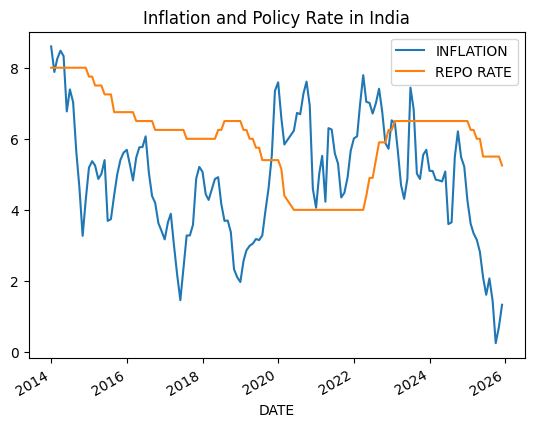

In [11]:
df[['INFLATION','REPO RATE']].plot(title = 'Inflation and Policy Rate in India')
plt.plot()


In [12]:
x =  df['INFLATION']
import statsmodels.api as sm

x = sm.add_constant(x)
y = df['REPO RATE']

model = sm.OLS(y, x).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              REPO RATE   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.007
Method:                 Least Squares   F-statistic:                   0.06637
Date:                Sat, 30 May 2026   Prob (F-statistic):              0.797
Time:                        22:36:26   Log-Likelihood:                -220.08
No. Observations:                 142   AIC:                             444.2
Df Residuals:                     140   BIC:                             450.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.0893      0.294     20.682      0.0

In [13]:
df['INFLATION_LAG'] = df['INFLATION'].shift(1)
df['REPO_LAG'] = df['REPO RATE'].shift(1)

df = df.dropna()

x = sm.add_constant(df[['INFLATION_LAG','REPO_LAG']])
y = df['REPO RATE']

model = sm.OLS(y,x).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              REPO RATE   R-squared:                       0.983
Model:                            OLS   Adj. R-squared:                  0.983
Method:                 Least Squares   F-statistic:                     3985.
Date:                Sat, 30 May 2026   Prob (F-statistic):          8.60e-123
Time:                        22:36:26   Log-Likelihood:                 69.647
No. Observations:                 141   AIC:                            -133.3
Df Residuals:                     138   BIC:                            -124.4
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -0.0240      0.078     -0.307